# Face Mask Detection using CNN

Data Collection

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)
data_dir = os.path.join(path, 'data')

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


Data Preprocessing and Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dimensions and batch size
img_height, img_width = 128, 128
batch_size = 32

# Data Augmentation and Rescaling
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
# Load Training Data
train_generator = datagen.flow_from_directory(
    path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

Found 6043 images belonging to 1 classes.


In [ ]:
# Load Validation Data
val_generator = datagen.flow_from_directory(
    path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 1510 images belonging to 1 classes.


Building CNN Model


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Convolutional Layer + ReLU + Maxpooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(2, 2),

    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Dropout
    layers.Flatten(),
    layers.Dropout(0.5), # Prevents overfitting

    # Fully Connected (Dense) Layer
    layers.Dense(64, activation='relu'),

    # Output Layer (Sigmoid for binary classification)
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Training

In [ ]:
# Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 2

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

Epoch 1/2
189/189 ━━━━━━━━━━━━━━━━━━━━ 172s 908ms/step - accuracy: 1.0000 - loss: 4.2517e-11 - val_accuracy: 1.0000 - val_loss: 2.4329e-13
Epoch 2/2
189/189 ━━━━━━━━━━━━━━━━━━━━ 172s 910ms/step - accuracy: 1.0000 - loss: 1.0859e-10 - val_accuracy: 1.0000 - val_loss: 1.9421e-14


Model Evaluation

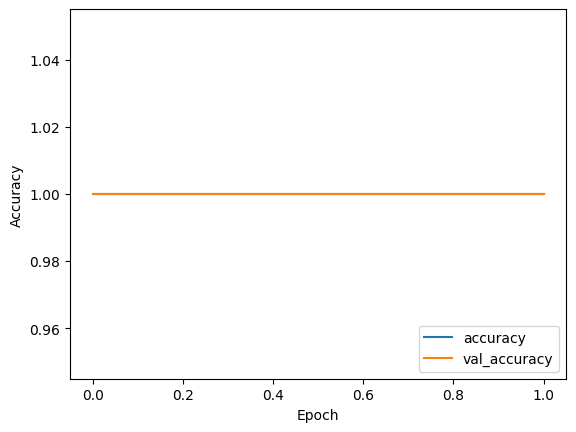

Model saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()
model.save('face_mask_detector.h5')
print("Model saved successfully!")

# Customer Segmentation using K-Means Clustering

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

 Load Data

In [ ]:
pd.read_csv('/content/Customer Purchasing Behaviors.csv')

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13
...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18


In [ ]:
df=pd.read_csv('/content/Customer Purchasing Behaviors.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


Basic Data Checks

In [ ]:
# shape and datatypes
print(df.info())
print(df.head())

# Removing duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical column (region)
le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['region'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
 7   region_encoded      238 non-null    int64  
 8   Cluster             238 non-null    int32  
dtypes: float64(1), int32(1), int64(6), object(1)
memory usage: 15.9+ KB
None
   user_id  age  annual_income  purchase_amount  loyalty_score region  \
0        1   25          45000              200            4.5  North   
1        2   34          55000              350            7.0  South   
2        3   45          65000              500            8

Exploratory Data Analysis (EDA)


Text(0.5, 1.0, 'Income Distribution')

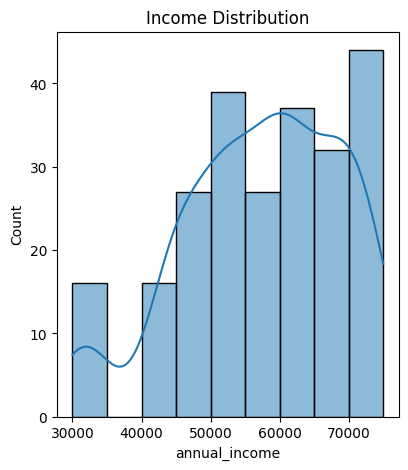

In [ ]:
# Univariate Analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['annual_income'], kde=True)
plt.title('Income Distribution')


Text(0.5, 1.0, 'Income vs Purchase Amount')

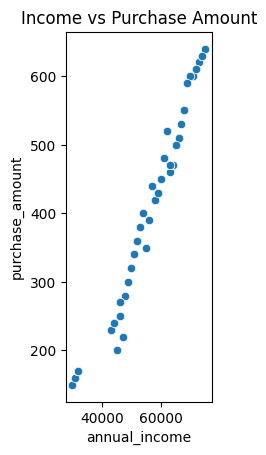

In [ ]:
# Bivariate Analysis: Income vs Purchase Amount
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='annual_income', y='purchase_amount')
plt.title('Income vs Purchase Amount')

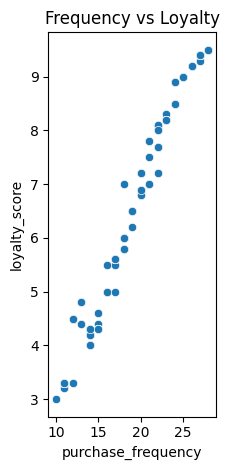

In [ ]:
# Bivariate Analysis: Frequency vs Loyalty
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='purchase_frequency', y='loyalty_score')
plt.title('Frequency vs Loyalty')
plt.tight_layout()
plt.show()

 Data Preprocessing and Feature Selection

In [ ]:
# Select features for clustering
features = ['annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score']
X = df[features]

In [ ]:
# Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

 Apply K-Means Clustering

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

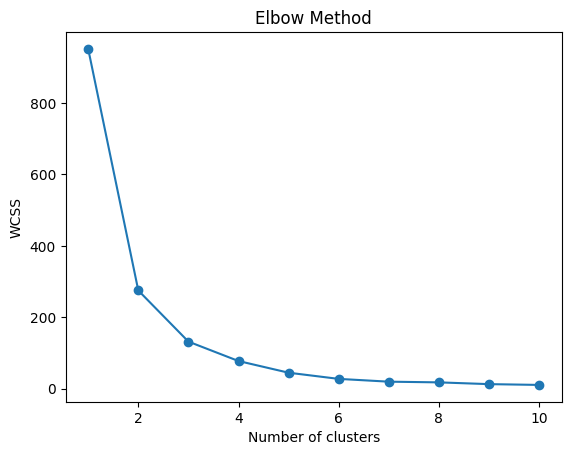

In [ ]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Customers successfully segmented into {optimal_k} clusters.")

Customers successfully segmented into 4 clusters.


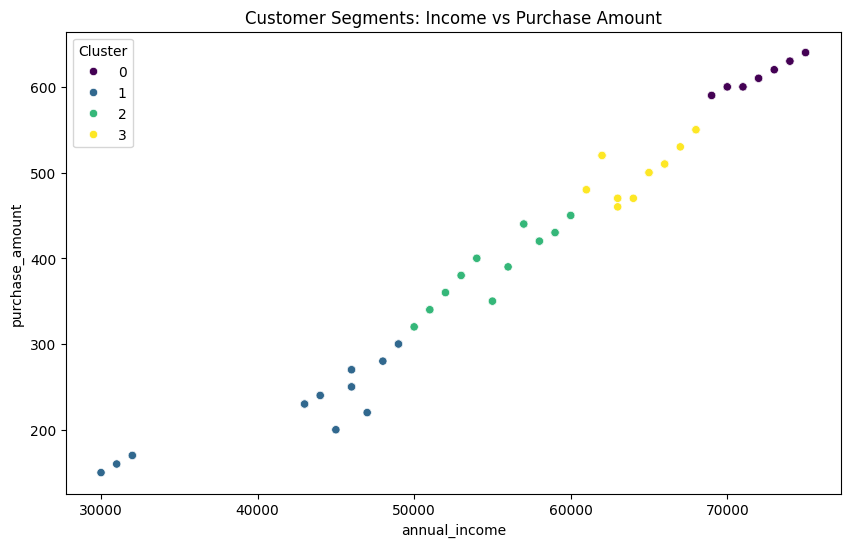

         annual_income  purchase_amount  purchase_frequency  loyalty_score
Cluster                                                                   
0         71557.692308       609.807692           25.711538       9.142308
1         41915.254237       230.338983           13.508475       4.091525
2         55136.986301       396.986301           18.958904       6.415068
3         63777.777778       500.370370           22.111111       7.998148


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='annual_income', y='purchase_amount', hue='Cluster', palette='viridis')
plt.title('Customer Segments: Income vs Purchase Amount')
plt.show()

# View segment averages
print(df.groupby('Cluster')[features].mean())